[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/skpm20_labs.ipynb)

# Data Analysis Labs

Download sample [dataset](https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/cod-260120.xlsx) and analyze the multivariate theoretical model illustrated below:

[![](https://mermaid.ink/img/pako:eNqVU9-L4jAQ_ldCZMGD6rZNa21OhGXl4OC4h1u4h1Mf0jRqsCYlTf2x4v9-02rVrvuyKZTkm_nmm8xMjpjrVGCKl4blK_Trz0whWKk0glupVY2csaJMzk4vimWHQhZo-oNxq02BxD4Hd5Eiq5FUi6wUigvEdW-nzVqAQy4MF3ILHoxzURQXR202rFKZnxUelRv0tnt6Qj9VKnIBP2XRX2YkSzJR3Dzk1utepRFbim_3Nv_OZnTWNpKuNkum5HudFbKHvLK3xCcP0ne5b73pdJSMbwqjxDyPHy5fo-0KjJ6T8Xz-QetVK3UuRvt6qNcbV2Kte30GkjYIiTcKEP03NB692UMm1fLSYTiIW3sXMstoZxFXn1NYo9eCdjjnl30vZcWKGcMOFIUovA9R5Xhh1-vKJoQ4XGfa0I7rum2K_3UK-SolvSYWetEgvl3LTwIvHDQsCHZXqAmre_lijN41BUNdmEIJ3YTAzFjELHIvowTm9Vut5jqe46NGAlJpKreTqV1RP99_xw68PJliak0pHLwRMA_VER-rYDNsV2IjZpjCNoU0ZnimTsDJmfqn9aahGV0uV5guWFbAqcxTZsVEMniumytqqrE1r7pUFtMwqmNgesR7TL142I-Gw2EcDEJCfJc4-AAoifpxFEdD33ODIPb9k4Pfa1G3PwgCKJ8bBlDq2Cfe6T-aRFOp?type=png)](https://mermaid.live/edit#pako:eNqVU9-L4jAQ_ldCZMGD6rZNa21OhGXl4OC4h1u4h1Mf0jRqsCYlTf2x4v9-02rVrvuyKZTkm_nmm8xMjpjrVGCKl4blK_Trz0whWKk0glupVY2csaJMzk4vimWHQhZo-oNxq02BxD4Hd5Eiq5FUi6wUigvEdW-nzVqAQy4MF3ILHoxzURQXR202rFKZnxUelRv0tnt6Qj9VKnIBP2XRX2YkSzJR3Dzk1utepRFbim_3Nv_OZnTWNpKuNkum5HudFbKHvLK3xCcP0ne5b73pdJSMbwqjxDyPHy5fo-0KjJ6T8Xz-QetVK3UuRvt6qNcbV2Kte30GkjYIiTcKEP03NB692UMm1fLSYTiIW3sXMstoZxFXn1NYo9eCdjjnl30vZcWKGcMOFIUovA9R5Xhh1-vKJoQ4XGfa0I7rum2K_3UK-SolvSYWetEgvl3LTwIvHDQsCHZXqAmre_lijN41BUNdmEIJ3YTAzFjELHIvowTm9Vut5jqe46NGAlJpKreTqV1RP99_xw68PJliak0pHLwRMA_VER-rYDNsV2IjZpjCNoU0ZnimTsDJmfqn9aahGV0uV5guWFbAqcxTZsVEMniumytqqrE1r7pUFtMwqmNgesR7TL142I-Gw2EcDEJCfJc4-AAoifpxFEdD33ODIPb9k4Pfa1G3PwgCKJ8bBlDq2Cfe6T-aRFOp)

- Perform descriptive statistics and data transformations
- Perform bivariate analyses and hypothesis testing
- Perform multivariate analysis, multiple regression

# Lab 1: Descriptive statistics and data transformations

## Setup and data loading

We focus on descriptive statistics and data transformation for the dataset `cod-260120.xlsx`. The cod dataset (Communicative Organizations Dataset) surveys attitudes toward communication among about 8,000 employees. The setup cell below loads the data and sets plotting defaults so later summaries are easy to read while keeping the raw values intact for analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Improve figure readability
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

# Load data (do not coerce numeric codes like 999 to missing)
path = "cod-260120.xlsx"
path = "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/cod-260120.xlsx"
df = pd.read_excel(path)

# Quick overview
print(df.shape)
print(df.columns[:10])

(8091, 58)
Index(['ID', 'Gender', 'Age', 'Org_type', 'Role', 'info_work', 'info_org',
       'info_vision', 'info_change', 'info_intracomm'],
      dtype='object')


## 1) Descriptive statistics

### Step 1: Inspect `Gender` and `femcomm_mgmt`

Goal: identify possible values and what the variables represent. The item `femcomm_mgmt` is a Likert scale variable where 1 means the respondent completely disagrees and 5 means the respondent completely agrees with the statement: “female communicators need to work harder to secure good relations with management.” We begin with frequency tables to see category balance, missingness, and to confirm the coding before any index variable or t-test work.

In [2]:
# Frequency table for Gender
print(df["Gender"].value_counts(dropna=False))

# Frequency table for femcomm_mgmt
print(df["femcomm_mgmt"].value_counts(dropna=False))

# Optional: inspect Org_type and Role labels
print(df["Org_type"].value_counts(dropna=False))
print(df["Role"].value_counts(dropna=False))

Gender
Female    4262
Male      2179
NaN       1631
Other       19
Name: count, dtype: int64
femcomm_mgmt
NaN    7685
1.0     113
4.0     103
2.0      71
5.0      63
3.0      56
Name: count, dtype: int64
Org_type
Public     6575
Private    1516
Name: count, dtype: int64
Role
Coworker                       6068
Manager                        1520
Communicator or equivalent      499
NaN                               4
Name: count, dtype: int64


### Step 2: Visualize `Gender` with a pie chart

Goal: replicate SPSS frequencies + chart.

This figure provides a quick descriptive view of group sizes, which matters when interpreting later mean comparisons or t-tests. Large imbalances can inflate uncertainty or make results sensitive to a small subgroup.

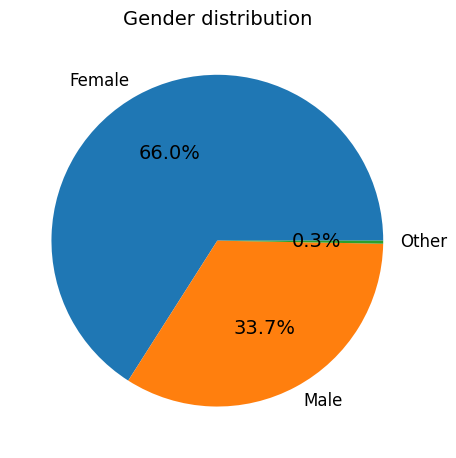

In [3]:
counts = df["Gender"].value_counts(dropna=True)
plt.figure()
plt.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%")
plt.title("Gender distribution")
plt.tight_layout()

Reflect: Is a pie chart a good way to visualize this variable? Would a bar chart be clearer?

### Step 3: Bar chart for `femcomm_mgmt`

Because `femcomm_mgmt` is part of the femcomm_* family of items, a bar chart helps us inspect the response pattern that will later contribute to an index variable. This also gives a sense of whether the item is skewed toward agreement or disagreement.

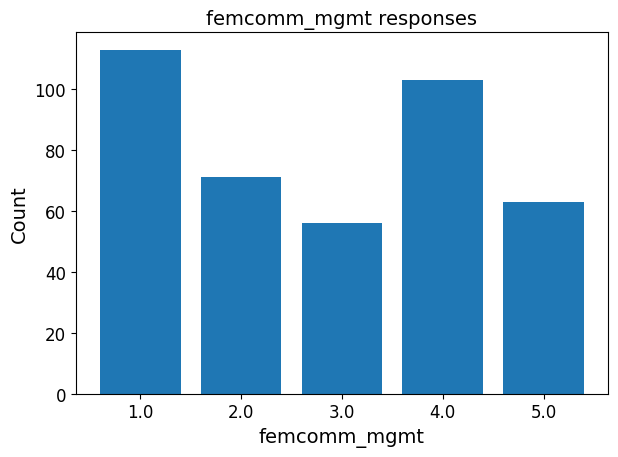

In [4]:
counts = df["femcomm_mgmt"].value_counts(dropna=True).sort_index()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("femcomm_mgmt")
plt.ylabel("Count")
plt.title("femcomm_mgmt responses")
plt.tight_layout()

### Step 4: Bar chart for `Role`

Compare the number of valid responses here with the number of valid responses for `femcomm_mgmt`. Role can signal whether femcomm_* questions were answered by particular subgroups, which affects how we interpret any gender differences. This check helps justify whether later comparisons should be stratified or filtered.

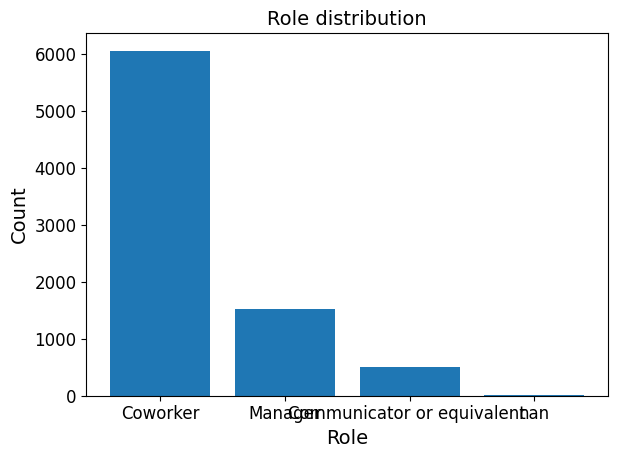

In [5]:
counts = df["Role"].value_counts(dropna=False)
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Role")
plt.ylabel("Count")
plt.title("Role distribution")
plt.tight_layout()

### Step 5: Find incorrect data in `Age`

In this dataset, `Age` is recorded as birth year. Look for unreasonable values. Cleaning implausible birth years is a standard preprocessing step. It prevents extreme values from distorting descriptive statistics and ensures that any downstream comparisons reflect realistic respondent ages.

count    6407.000000
mean     1967.794756
std        14.551539
min      1182.000000
25%      1959.000000
50%      1967.000000
75%      1976.000000
max      2084.000000
Name: Age, dtype: float64


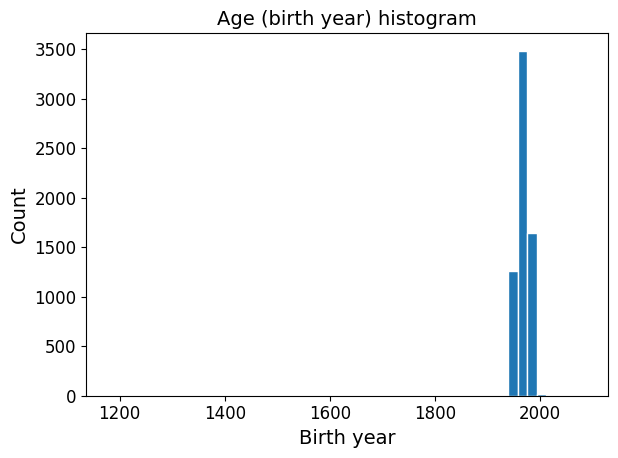

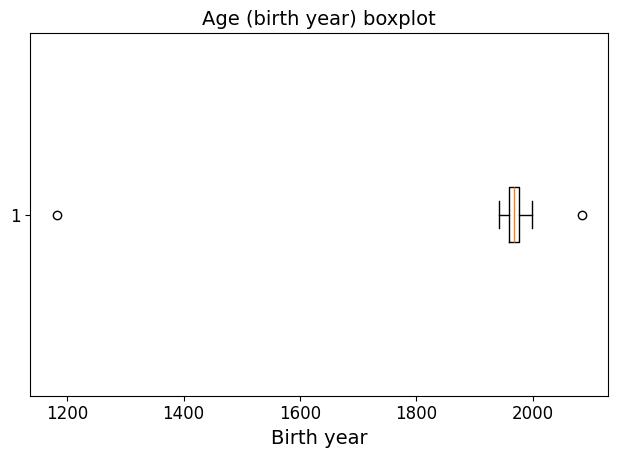

In [6]:
print(df["Age"].describe())

plt.figure()
plt.hist(df["Age"].dropna(), bins=50, edgecolor="white")
plt.xlabel("Birth year")
plt.ylabel("Count")
plt.title("Age (birth year) histogram")
plt.tight_layout()

# Boxplot for outliers
plt.figure()
plt.boxplot(df["Age"].dropna(), vert=False)
plt.xlabel("Birth year")
plt.title("Age (birth year) boxplot")
plt.tight_layout()

Identify potential outliers using the IQR rule and inspect those cases.

In [7]:
age = df["Age"].dropna()
q1, q3 = age.quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]
print(outliers[["Age"]].head(10))

         Age
3610  1182.0
3908  2084.0


If you decide values are incorrect, you can replace them with the median birth year.

In [8]:
median_birth_year = df["Age"].median()
# Example: replace outliers with the median
df.loc[(df["Age"] < lower) | (df["Age"] > upper), "Age"] = median_birth_year

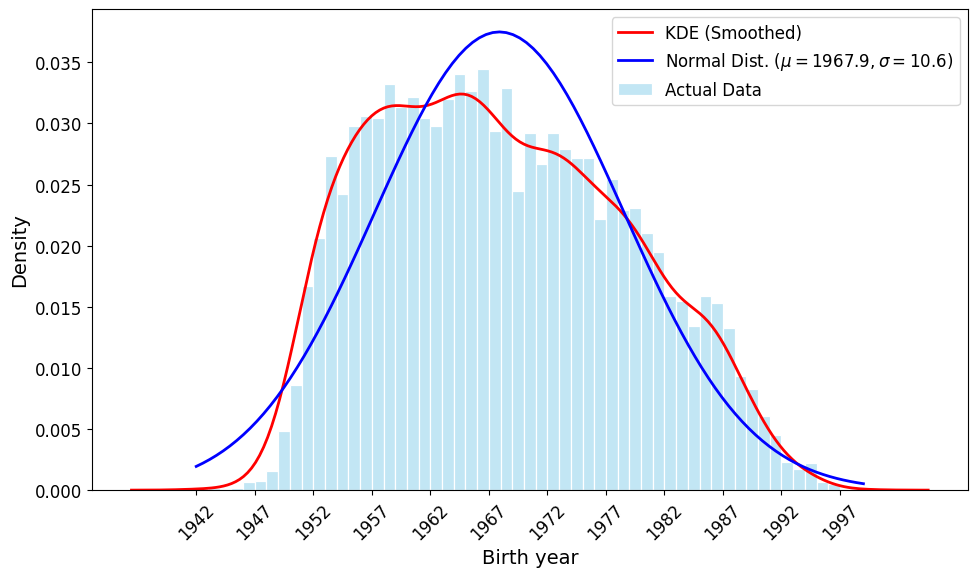

In [9]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# Clean the data
age_clean = df["Age"].dropna().astype(int)

# 1. Calculate the exact range of years
start_year = age_clean.min()
end_year = age_clean.max()

# 2. Create bins for every single year (plus one for the final edge)
# This ensures each year gets its own dedicated bar
year_bins = range(start_year, end_year + 2)

# 1. Calculate parameters
mu = age_clean.mean()
sigma = age_clean.std()

plt.figure(figsize=(10, 6))

# 2. Histogram
sns.histplot(age_clean, bins=year_bins, stat="density", color="skyblue",
             edgecolor="white", alpha=0.5, label="Actual Data")

# 3. KDE
sns.kdeplot(age_clean, color="red", linewidth=2, label="KDE (Smoothed)")

# 4. Normal Curve - Note the 'r' prefix for the label
x = np.linspace(age_clean.min(), age_clean.max(), 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'b', linewidth=2,
         label=r'Normal Dist. ($\mu={:.1f}, \sigma={:.1f}$)'.format(mu, sigma))

# Formatting
plt.xticks(range(int(age_clean.min()), int(age_clean.max()) + 1, 5), rotation=45)
plt.xlabel("Birth year")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### Step 6: Crosstabs

#### 6a) `Gender` by `femcomm_mgmt` with column percentages

This crosstab explores how gender groups differ in the femcomm_mgmt item before any formal t-test. Column percentages allow comparison even when group sizes are unequal.

In [10]:
ct = pd.crosstab(df["femcomm_mgmt"], df["Gender"], dropna=False)
col_pct = ct.div(ct.sum(axis=0), axis=1) * 100
print(ct)
print(col_pct.round(1))

Gender        Female  Male  Other   NaN
femcomm_mgmt                           
1.0               54    51      0     8
2.0               47    21      0     3
3.0               38    16      0     2
4.0               90    11      0     2
5.0               58     2      0     3
NaN             3975  2078     19  1613
Gender        Female  Male  Other   NaN
femcomm_mgmt                           
1.0              1.3   2.3    0.0   0.5
2.0              1.1   1.0    0.0   0.2
3.0              0.9   0.7    0.0   0.1
4.0              2.1   0.5    0.0   0.1
5.0              1.4   0.1    0.0   0.2
NaN             93.3  95.4  100.0  98.9


#### 6b) `Role` by `extcomm`

The variable `extcomm` captures attitudes about communicators’ contributions to effective external communication. Comparing it to Role can reveal whether job roles align with different beliefs about external communication effectiveness.

In [11]:
ct = pd.crosstab(df["extcomm"], df["Role"], dropna=False)
print(ct)

Role     Communicator or equivalent   Coworker  Manager  NaN
extcomm                                                     
1.0                                1       124       23    0
2.0                                8       230       70    0
3.0                               10       750      151    1
4.0                              100      1749      535    1
5.0                              370      2007      612    0
NaN                               10      1208      129    2


### Step 7: Compare means

Compare mean age (birth year) across responses to `org_gossip`.

The `org_gossip` variable measures attitudes about whether gossip is a problem in organizational workplaces. Group means here preview differences across response categories and set up the logic that will later be formalized with a t-test or ANOVA.

In [12]:
means = df.groupby("org_gossip")["Age"].mean()
print(means)

org_gossip
1.0    1968.806402
2.0    1969.316843
3.0    1967.262064
4.0    1968.218900
5.0    1969.062402
Name: Age, dtype: float64


## 2) Data transformation

### Step 1: Recode `org_gossip` into 3 categories

Recode to: 1=disagree (1,2), 2=neither (3), 3=agree (4,5). This recode creates broader categories that are easier to interpret and can stabilize small cell counts. It is a typical transformation step prior to cross-tabs or mean comparisons.

In [13]:
# ensure numeric
org = pd.to_numeric(df["org_gossip"], errors="coerce")

def recode_org_gossip(x):
    if pd.isna(x):
        return np.nan
    if x in [1, 2]:
        return 1
    if x == 3:
        return 2
    if x in [4, 5]:
        return 3
    return np.nan


df["org_gossip_cat"] = org.apply(recode_org_gossip)

# check frequencies
print(df["org_gossip"].value_counts(dropna=False))
print(df["org_gossip_cat"].value_counts(dropna=False))

org_gossip
4.0    2263
3.0    1678
NaN    1453
5.0    1007
2.0     972
1.0     718
Name: count, dtype: int64
org_gossip_cat
3.0    3270
1.0    1690
2.0    1678
NaN    1453
Name: count, dtype: int64


Cross tab with `Role` to compare patterns more clearly. After recoding, this table checks whether perceptions of gossip differ by organizational role, which can inform later modeling choices.

In [14]:
ct = pd.crosstab(df["org_gossip_cat"], df["Role"], dropna=False)
print(ct)

Role            Communicator or equivalent   Coworker  Manager  NaN
org_gossip_cat                                                     
1.0                                     144      1200      344    2
2.0                                      91      1315      272    0
3.0                                     178      2349      743    0
NaN                                      86      1204      161    2


### Step 2: Compute age in years

Age is stored as birth year. Compute age in years using 2016 as the reference year. This transformation yields an interpretable age variable for reporting means and variability. It also allows us to compare age distributions across subgroups or responses later in the lab.

count    6407.000000
mean       48.100983
std        10.641371
min        17.000000
25%        40.000000
50%        49.000000
75%        57.000000
max        74.000000
Name: age_years, dtype: float64


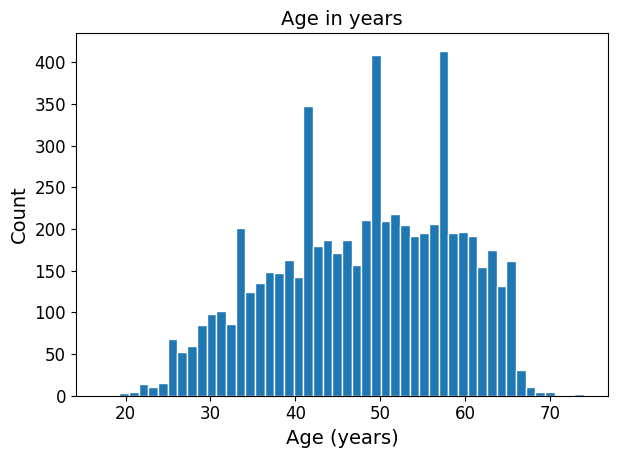

In [15]:
# Optionally fix obvious outliers before computing age in years
# df.loc[(df["Age"] < lower) | (df["Age"] > upper), "Age"] = median_birth_year

df["age_years"] = 2016 - df["Age"]
print(df["age_years"].describe())

plt.figure()
plt.hist(df["age_years"].dropna(), bins=50, edgecolor="white")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.title("Age in years")
plt.tight_layout()

### Step 3: Build an index from femcomm items

Use the items:
- `femcomm_performance`
- `femcomm_mgmt`
- `femcomm_opportunity`
- `femcomm_support`
- `femcomm_barriers`

Check coding direction before combining. The femcomm_* items are similarly constructed Likert variables capturing different aspects of gender equality for female communicators. We evaluate their internal consistency with Cronbach's alpha and then create an index variable to summarize the overall construct.

femcomm_performance
femcomm_performance
1.0     119
2.0      72
3.0      59
4.0      98
5.0      54
NaN    7689
Name: count, dtype: int64
femcomm_mgmt
femcomm_mgmt
1.0     113
2.0      71
3.0      56
4.0     103
5.0      63
NaN    7685
Name: count, dtype: int64
femcomm_opportunity
femcomm_opportunity
1.0     125
2.0      83
3.0      74
4.0      65
5.0      44
NaN    7700
Name: count, dtype: int64
femcomm_support
femcomm_support
1.0     100
2.0      39
3.0      70
4.0      28
5.0      18
NaN    7836
Name: count, dtype: int64
femcomm_barriers
femcomm_barriers
1.0      80
2.0      49
3.0      52
4.0     105
5.0      72
NaN    7733
Name: count, dtype: int64
Cronbach's alpha: 0.958
count    427.000000
mean      11.590164
std        6.248245
min        1.000000
25%        5.000000
50%       11.000000
75%       16.000000
max       25.000000
Name: femcomm_index, dtype: float64


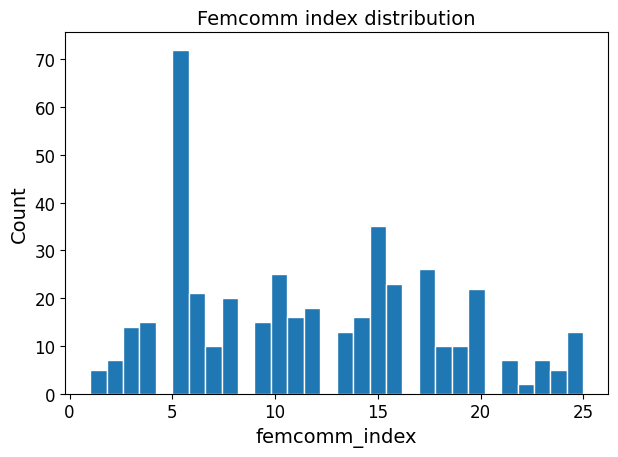

In [16]:
items = [
    "femcomm_performance",
    "femcomm_mgmt",
    "femcomm_opportunity",
    "femcomm_support",
    "femcomm_barriers",
]

# frequency tables
for col in items:
    print(col)
    print(df[col].value_counts(dropna=False).sort_index())

# Cronbach's alpha (basic implementation)
item_df = df[items].dropna()
item_scores = item_df.to_numpy(dtype=float)

k = item_scores.shape[1]
item_variances = item_scores.var(axis=0, ddof=1)
total_variance = item_scores.sum(axis=1).var(ddof=1)
alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
print(f"Cronbach's alpha: {alpha:.3f}")

# Summative index
# (If any items require reverse coding, do that before summing.)
df["femcomm_index"] = df[items].sum(axis=1, min_count=1)
print(df["femcomm_index"].describe())

plt.figure()
plt.hist(df["femcomm_index"].dropna(), bins=30, edgecolor="white")
plt.xlabel("femcomm_index")
plt.ylabel("Count")
plt.title("Femcomm index distribution")
plt.tight_layout()

Lets do the same thing again, but exclude missing values and fix binning issues!


--- femcomm_performance ---
femcomm_performance
1.0    119
2.0     72
3.0     59
4.0     98
5.0     54
Name: count, dtype: int64

--- femcomm_mgmt ---
femcomm_mgmt
1.0    113
2.0     71
3.0     56
4.0    103
5.0     63
Name: count, dtype: int64

--- femcomm_opportunity ---
femcomm_opportunity
1.0    125
2.0     83
3.0     74
4.0     65
5.0     44
Name: count, dtype: int64

--- femcomm_support ---
femcomm_support
1.0    100
2.0     39
3.0     70
4.0     28
5.0     18
Name: count, dtype: int64

--- femcomm_barriers ---
femcomm_barriers
1.0     80
2.0     49
3.0     52
4.0    105
5.0     72
Name: count, dtype: int64

Cronbach's alpha: 0.958

--- Index Summary Statistics ---
count    241.000000
mean      12.879668
std        6.533730
min        5.000000
25%        5.000000
50%       13.000000
75%       18.000000
max       25.000000
Name: femcomm_index, dtype: float64


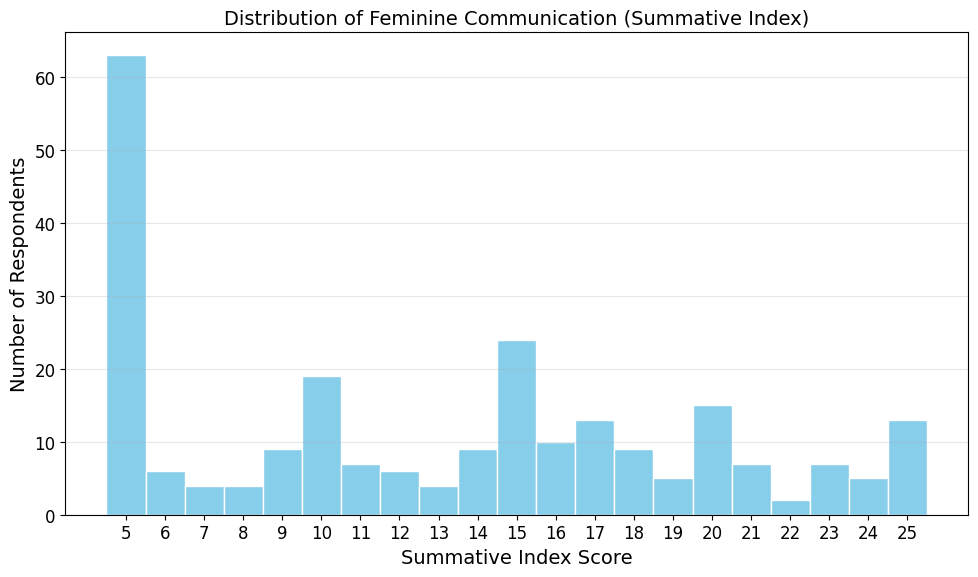

In [17]:
import numpy as np
import matplotlib.pyplot as plt

items = [
    "femcomm_performance",
    "femcomm_mgmt",
    "femcomm_opportunity",
    "femcomm_support",
    "femcomm_barriers",
]

# 1. Frequency tables (Excluding missing for the count, but showing them for audit)
for col in items:
    print(f"\n--- {col} ---")
    # Using dropna=True to see the valid distribution for your lecture
    print(df[col].value_counts(dropna=True).sort_index())

# 2. Cronbach's alpha
item_df = df[items].dropna()
item_scores = item_df.to_numpy(dtype=float)

k = item_scores.shape[1]
item_variances = item_scores.var(axis=0, ddof=1)
total_variance = item_scores.sum(axis=1).var(ddof=1)
alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
print(f"\nCronbach's alpha: {alpha:.3f}")

# 3. Summative index
# min_count=len(items) ensures we only get a score if ALL items are answered
df["femcomm_index"] = df[items].sum(axis=1, min_count=len(items))
index_data = df["femcomm_index"].dropna()

print("\n--- Index Summary Statistics ---")
print(index_data.describe())

# 4. Histogram with discrete binning
plt.figure(figsize=(10, 6))

# Calculate discrete bins: one bin for every integer in the index range
idx_min = int(index_data.min())
idx_max = int(index_data.max())
# range(start, stop) goes to stop-1, so we add 2 to include the final bar edge
bins_discrete = range(idx_min, idx_max + 2)

plt.hist(index_data, bins=bins_discrete, edgecolor="white", align='left', color='skyblue')

# Force x-ticks to be integers so they align with the index values
plt.xticks(range(idx_min, idx_max + 1))

plt.xlabel("Summative Index Score")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Feminine Communication (Summative Index)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 4: Hypothesis test (gender differences)

Compare index means between genders (female vs male). Use a two-sample t-test. This t-test examines whether the femcomm index variable differs between gender groups. Because the index aggregates multiple items, the test reflects overall attitudes toward gender equality rather than a single question.

In [18]:
from scipy import stats

# Use actual Gender labels from the dataset
female = df[df["Gender"] == "Female"]["femcomm_index"].dropna()
male = df[df["Gender"] == "Male"]["femcomm_index"].dropna()

print("Female mean:", female.mean())
print("Male mean:", male.mean())

# Welch's t-test (does not assume equal variances)
res = stats.ttest_ind(female, male, equal_var=False)
print(res)

Female mean: 14.602484472049689
Male mean: 9.074626865671641
TtestResult(statistic=np.float64(6.979168009228572), pvalue=np.float64(8.090511271065262e-11), df=np.float64(155.36834016726473))


Interpretation: if the p-value is below 0.05, the difference is statistically significant.

---

## Wrap-up

You now have a Python-based workflow for the descriptive statistics and data transformation tasks in computer lab 1. Save the modified dataset to a local tsv file in preparation for computer lab 2 on bivariate analysis and hypothesis testing!

In [19]:
# Save the dataframe to a TSV file
df.to_csv('cod-260204.tsv', sep='\t', index=False)

# Lab 2: Bivariate Analysis and Hypothesis Testing

This lab converts the SPSS-based instructions from `jnb/workshop-3.qmd` into a Python workflow for bivariate analysis and hypothesis testing using the cod dataset (Communicative Organizations Dataset). The cod dataset investigates attitudes to communication among about 8,000 employees. We focus on creating an index variable, describing key variables, and running bivariate tests (correlations, t-tests, and ANOVA).

## Setup and data loading

We load `cod-260204.tsv` and inspect the columns to confirm variable names before analysis.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load the dataset
path = "cod-260204.tsv"
path = "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/cod-260204.tsv"
df = pd.read_csv(path, sep="\t")

print(df.shape)
print(df.columns[:15])

(8091, 61)
Index(['ID', 'Gender', 'Age', 'Org_type', 'Role', 'info_work', 'info_org',
       'info_vision', 'info_change', 'info_intracomm', 'info_mgmttrust',
       'info_mgmttocow', 'info_cowtomgmt', 'org_openmind',
       'org_intracommtrust'],
      dtype='object')


## 1) Univariate analysis: create an index variable

### Step 1: Build `infoaccess_index`

The `info_*` variables are Likert-scale items (1 = completely disagree, 5 = completely agree) capturing access to information in different aspects of organizational work life. We combine them into an **index variable** called `infoaccess_index` to summarize overall perceived access to information. Before using the index, we compute basic descriptive statistics and visualize its distribution. (An index variable is a composite score created by summing or averaging several related items.)

--- Info Access Index Summary ---
count    6324.000000
mean       21.490354
std         5.425620
min         6.000000
25%        18.000000
50%        23.000000
75%        26.000000
max        30.000000
Name: infoaccess_index, dtype: float64


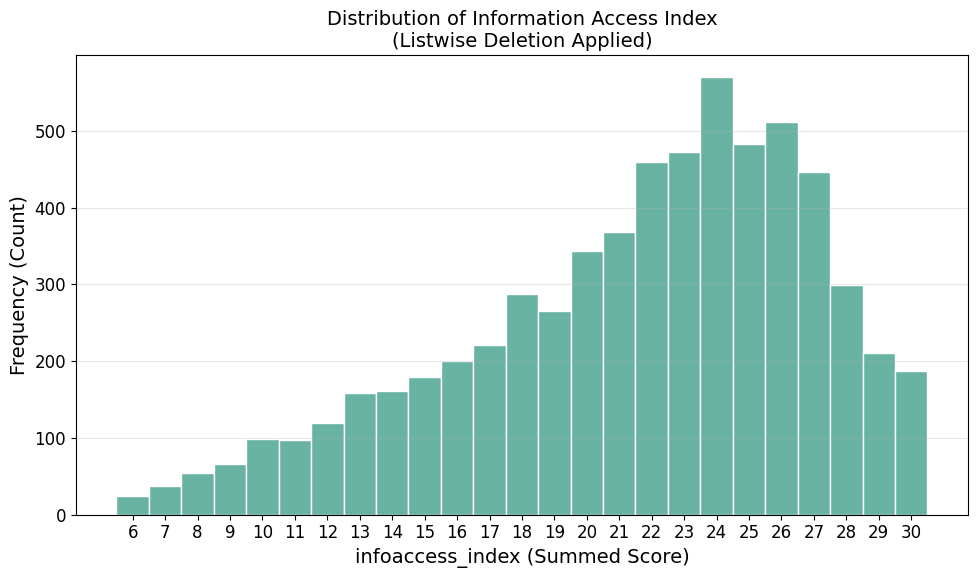

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

info_items = [
    "info_work",
    "info_org",
    "info_vision",
    "info_change",
    "info_intracomm",
    "info_mgmttrust",
]

# 1. Ensure numeric (and coerce errors to NaN)
for col in info_items:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2. Compute summative index
# min_count=len(info_items) ensures we EXCLUDE rows with ANY missing values
df["infoaccess_index"] = df[info_items].sum(axis=1, min_count=len(info_items))

# Filter for clean data for plotting
index_clean = df["infoaccess_index"].dropna()

# 3. Descriptives
print("--- Info Access Index Summary ---")
print(index_clean.describe())

# 4. Distribution with discrete binning
plt.figure(figsize=(10, 6))

# Calculate one bin per possible integer score
idx_min, idx_max = int(index_clean.min()), int(index_clean.max())
bins_discrete = range(idx_min, idx_max + 2) # +2 to close the last bar edge

plt.hist(index_clean, bins=bins_discrete, edgecolor="white", align='left', color='#69b3a2')

# Formatting
plt.xticks(range(idx_min, idx_max + 1))
plt.xlabel("infoaccess_index (Summed Score)")
plt.ylabel("Frequency (Count)")
plt.title("Distribution of Information Access Index\n(Listwise Deletion Applied)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 2: Inspect key background variables

We examine `Age`, `Gender`, `Role`, and `Org_type` to understand their measurement scales (quantitative vs. qualitative) and distributions. This contextualizes which bivariate tests are appropriate.

In [22]:
print(df["age_years"].describe())
print(df["Gender"].value_counts(dropna=False))
print(df["Role"].value_counts(dropna=False))
print(df["Org_type"].value_counts(dropna=False))

count    6407.000000
mean       48.100983
std        10.641371
min        17.000000
25%        40.000000
50%        49.000000
75%        57.000000
max        74.000000
Name: age_years, dtype: float64
Gender
Female    4262
Male      2179
NaN       1631
Other       19
Name: count, dtype: int64
Role
Coworker                       6068
Manager                        1520
Communicator or equivalent      499
NaN                               4
Name: count, dtype: int64
Org_type
Public     6575
Private    1516
Name: count, dtype: int64


## 2) Bivariate analysis


### Step 3: Compare `infoaccess_index` to background variables

We use different tests depending on variable type:
- **Correlation** for quantitative variables (e.g., Age)
- **t-test** for two-group comparisons (e.g., Female vs Male)
- **ANOVA** for more than two categories (e.g., Role or Org_type)

In [23]:
# Correlation with Age (quantitative vs quantitative)
sub = df[["age_years", "infoaccess_index"]].dropna()
print("Correlation (Age vs infoaccess_index):", sub.corr().iloc[0, 1])

# t-test for Gender (two groups)
female = df[df["Gender"] == "Female"]["infoaccess_index"].dropna()
male = df[df["Gender"] == "Male"]["infoaccess_index"].dropna()

print("Female mean:", female.mean())
print("Male mean:", male.mean())
if len(female) > 1 and len(male) > 1:
    print(stats.ttest_ind(female, male, equal_var=False))

# ANOVA for Role (more than two groups)
role_groups = [g["infoaccess_index"].dropna().values for _, g in df.groupby("Role")]
role_groups = [g for g in role_groups if len(g) > 1]
if len(role_groups) >= 2:
    print(stats.f_oneway(*role_groups))

# ANOVA for Org_type
org_groups = [g["infoaccess_index"].dropna().values for _, g in df.groupby("Org_type")]
org_groups = [g for g in org_groups if len(g) > 1]
if len(org_groups) >= 2:
    print(stats.f_oneway(*org_groups))

Correlation (Age vs infoaccess_index): 0.07429677271005702
Female mean: 22.922910216718265
Male mean: 22.315354980737478
TtestResult(statistic=np.float64(4.4118285547652105), pvalue=np.float64(1.0550667114769715e-05), df=np.float64(3595.399925429104))
F_onewayResult(statistic=np.float64(118.9004029119778), pvalue=np.float64(2.0423777284803505e-51))
F_onewayResult(statistic=np.float64(66.49042585482461), pvalue=np.float64(4.204354427135523e-16))


To interpret the hypothesis tests, add simple visual checks of the same relationships. Scatterplots show correlation patterns, while boxplots show group differences that correspond to the t-test and ANOVA outputs.

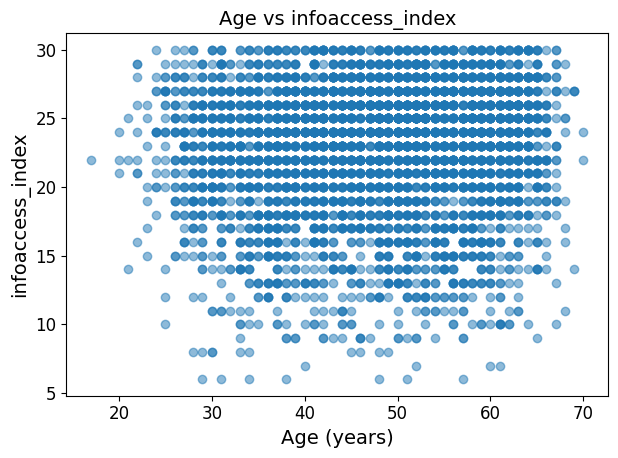

In [24]:
# Age vs infoaccess_index (correlation)
plt.figure()
plt.scatter(sub["age_years"], sub["infoaccess_index"], alpha=0.5)
plt.xlabel("Age (years)")
plt.ylabel("infoaccess_index")
plt.title("Age vs infoaccess_index")
plt.tight_layout()

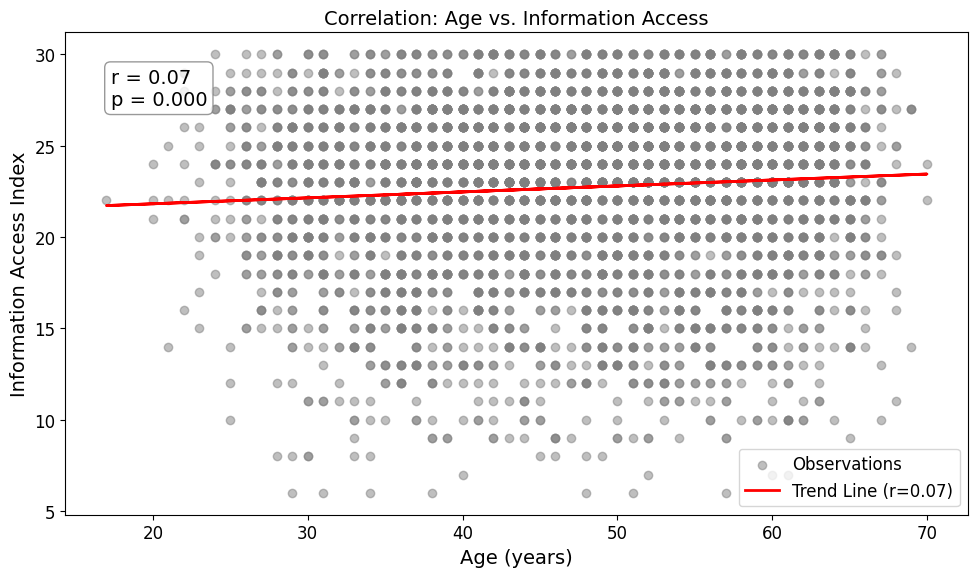

In [25]:
import numpy as np
from scipy import stats

# 1. Prepare clean data (regression fails with NaNs)
clean_data = sub.dropna(subset=["age_years", "infoaccess_index"])
x = clean_data["age_years"]
y = clean_data["infoaccess_index"]

# 2. Calculate linear regression parameters
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

plt.figure(figsize=(10, 6))

# 3. Plot the scatter points
plt.scatter(x, y, alpha=0.5, label="Observations", color="gray")

# 4. Plot the trend line
# We calculate y-values for the start and end of the x-axis
line = slope * x + intercept
plt.plot(x, line, color="red", linewidth=2, label=f"Trend Line (r={r_value:.2f})")

# Formatting
plt.xlabel("Age (years)")
plt.ylabel("Information Access Index")
plt.title("Correlation: Age vs. Information Access")

# Optional: Add stats annotation to the plot for the lecture
plt.annotate(f"r = {r_value:.2f}\np = {p_value:.3f}",
             xy=(0.05, 0.85), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.legend()
plt.tight_layout()
plt.show()

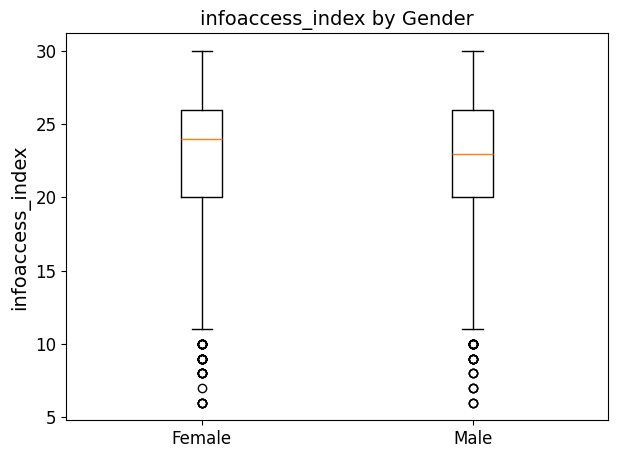

In [26]:
# Gender vs infoaccess_index (t-test)
plt.figure()
plt.boxplot([female, male], tick_labels=["Female", "Male"])
plt.ylabel("infoaccess_index")
plt.title("infoaccess_index by Gender")
plt.tight_layout()

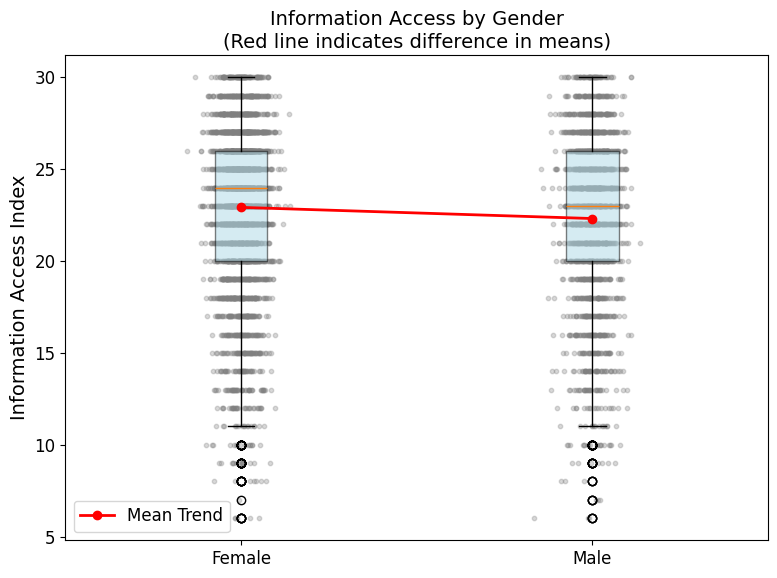

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data (ensure NaNs are dropped for calculation)
f_clean = female.dropna()
m_clean = male.dropna()

# 2. Calculate means for the "trend" line
means = [f_clean.mean(), m_clean.mean()]
x_positions = [1, 2] # Boxplots are at x=1 and x=2 by default

plt.figure(figsize=(8, 6))

# 3. Create the boxplot
plt.boxplot([f_clean, m_clean], tick_labels=["Female", "Male"], patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.5))

# 4. Add the "Trend Line" connecting the means
plt.plot(x_positions, means, color="red", marker="o", linewidth=2, label="Mean Trend")

# 5. Optional: Add individual data points (jittered) to show distribution density
plt.scatter(np.random.normal(1, 0.04, size=len(f_clean)), f_clean, alpha=0.3, s=10, color='gray')
plt.scatter(np.random.normal(2, 0.04, size=len(m_clean)), m_clean, alpha=0.3, s=10, color='gray')

# Formatting
plt.ylabel("Information Access Index")
plt.title("Information Access by Gender\n(Red line indicates difference in means)")
plt.legend()
plt.tight_layout()
plt.show()

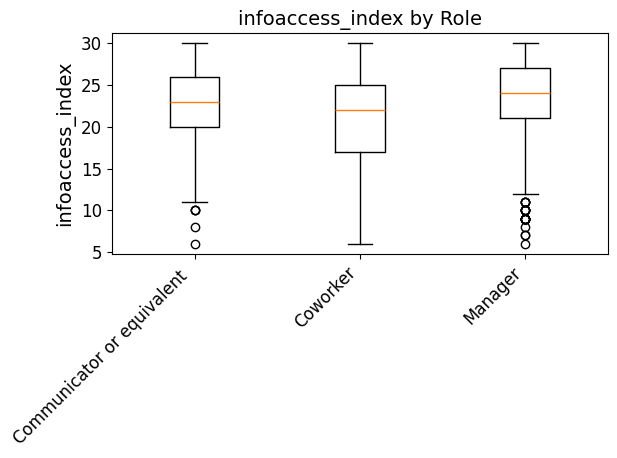

In [28]:
# Role vs infoaccess_index (ANOVA)
plt.figure()
role_labels = []
role_data = []
for role, g in df.groupby("Role"):
    vals = g["infoaccess_index"].dropna()
    if len(vals) > 1:
        role_labels.append(role)
        role_data.append(vals.values)
plt.boxplot(role_data, tick_labels=role_labels)
plt.xticks(rotation=45, ha="right")
plt.ylabel("infoaccess_index")
plt.title("infoaccess_index by Role")
plt.tight_layout()

### Step 4: Pairwise relationships among background variables

Here we compare background variables with each other using appropriate tests: cross-tabs for categorical pairs, and correlation for quantitative pairs.

In [29]:
# Gender by Role (categorical vs categorical)
ct = pd.crosstab(df["Gender"], df["Role"], dropna=False)
print(ct)

# Gender by Org_type
ct = pd.crosstab(df["Gender"], df["Org_type"], dropna=False)
print(ct)

# Age by Role (compare means across categories)
age_by_role = df.groupby("Role")["age_years"].mean()
print(age_by_role)

Role    Communicator or equivalent   Coworker  Manager  NaN
Gender                                                     
Female                          339      3205      718    0
Male                            136      1489      552    2
Other                             0        16        3    0
NaN                              24      1358      247    2
Org_type  Private  Public
Gender                   
Female        540    3722
Male          965    1214
Other           4      15
NaN             7    1624
Role
Communicator or equivalent     44.466527
Coworker                       47.937996
Manager                        50.076619
Name: age_years, dtype: float64


Visualizing the cross-tabs helps identify which category combinations drive any association. A heatmap is a compact way to display these frequencies.

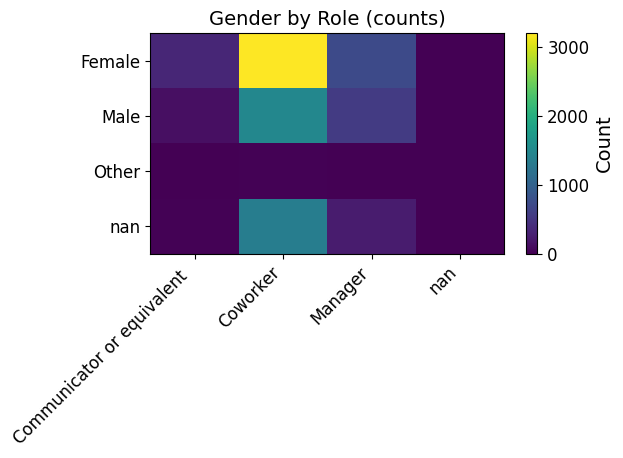

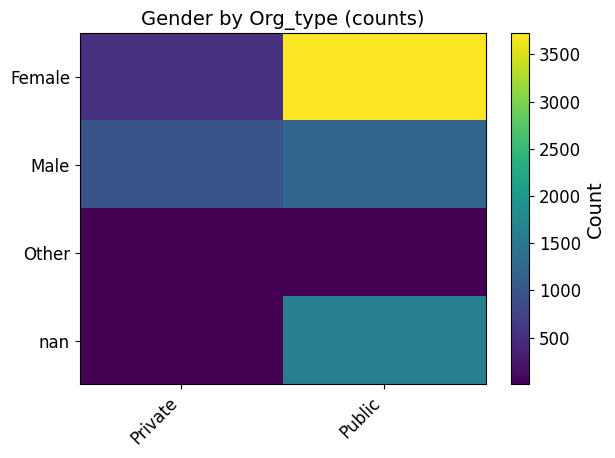

In [30]:
# Heatmap: Gender by Role
ct = pd.crosstab(df["Gender"], df["Role"], dropna=False)
plt.figure()
plt.imshow(ct.values, aspect="auto")
plt.colorbar(label="Count")
plt.xticks(range(len(ct.columns)), ct.columns, rotation=45, ha="right")
plt.yticks(range(len(ct.index)), ct.index)
plt.title("Gender by Role (counts)")
plt.tight_layout()

# Heatmap: Gender by Org_type
ct = pd.crosstab(df["Gender"], df["Org_type"], dropna=False)
plt.figure()
plt.imshow(ct.values, aspect="auto")
plt.colorbar(label="Count")
plt.xticks(range(len(ct.columns)), ct.columns, rotation=45, ha="right")
plt.yticks(range(len(ct.index)), ct.index)
plt.title("Gender by Org_type (counts)")
plt.tight_layout()

## 3) Creating dummy variables

Dummy variables are binary indicators (0/1) that represent categories in a qualitative variable. They are essential for regression models and for comparing specific groups.


### Step 5: Dummy coding for Gender

We recode Gender into `dummy_gender` where Female=1 and Male=0. Other values (e.g., missing or non-binary categories) are set to NA.

In [31]:
# Normalize Gender text
gender_str = df["Gender"].astype(str).str.lower()

# Female = 1, Male = 0, else NA
# (Use np.nan to keep missing/other categories explicit)
df["dummy_gender"] = np.where(gender_str == "female", 1,
                      np.where(gender_str == "male", 0, np.nan))

print(df["Gender"].value_counts(dropna=False))
print(df["dummy_gender"].value_counts(dropna=False))

Gender
Female    4262
Male      2179
NaN       1631
Other       19
Name: count, dtype: int64
dummy_gender
1.0    4262
0.0    2179
NaN    1650
Name: count, dtype: int64


### Step 6: Dummy coding for Role

We create three dummy variables for Role: `dummy_manager`, `dummy_communicator`, and `dummy_coworker`. Each equals 1 if the respondent is in that role and 0 otherwise.

In [32]:
role_str = df["Role"].astype(str).str.lower()

# Create binary indicators
# Set to NaN if Role is missing
is_missing_role = df["Role"].isna()

df["dummy_manager"] = np.where(is_missing_role, np.nan, role_str.str.contains("manager").astype(int))
df["dummy_communicator"] = np.where(is_missing_role, np.nan, role_str.str.contains("communicator").astype(int))
df["dummy_coworker"] = np.where(is_missing_role, np.nan, role_str.str.contains("coworker").astype(int))

#print(df[["Role", "dummy_manager", "dummy_communicator", "dummy_coworker"]].head(10))
print(df["Role"].value_counts(dropna=False))
print(df["dummy_manager"].value_counts(dropna=False))
print(df["dummy_communicator"].value_counts(dropna=False))
print(df["dummy_coworker"].value_counts(dropna=False))

Role
Coworker                       6068
Manager                        1520
Communicator or equivalent      499
NaN                               4
Name: count, dtype: int64
dummy_manager
0.0    6567
1.0    1520
NaN       4
Name: count, dtype: int64
dummy_communicator
0.0    7588
1.0     499
NaN       4
Name: count, dtype: int64
dummy_coworker
1.0    6068
0.0    2019
NaN       4
Name: count, dtype: int64


## Wrap-up

You have built an index variable (`infoaccess_index`), run descriptive checks, and completed bivariate analyses using correlations, t-tests, and ANOVA. You also created dummy variables for Gender and Role, which will be required for multivariate analysis in Lab 3.

In [33]:
# Save the dataframe to a TSV file
df.to_csv('cod-260210.tsv', sep='\t', index=False)

# Lab 3: Multivariate analysis, multiple regression

[![](https://mermaid.ink/img/pako:eNqVU9-L4jAQ_ldCZMGD6rZNa21OhGXl4OC4h1u4h1Mf0jRqsCYlTf2x4v9-02rVrvuyKZTkm_nmm8xMjpjrVGCKl4blK_Trz0whWKk0glupVY2csaJMzk4vimWHQhZo-oNxq02BxD4Hd5Eiq5FUi6wUigvEdW-nzVqAQy4MF3ILHoxzURQXR202rFKZnxUelRv0tnt6Qj9VKnIBP2XRX2YkSzJR3Dzk1utepRFbim_3Nv_OZnTWNpKuNkum5HudFbKHvLK3xCcP0ne5b73pdJSMbwqjxDyPHy5fo-0KjJ6T8Xz-QetVK3UuRvt6qNcbV2Kte30GkjYIiTcKEP03NB692UMm1fLSYTiIW3sXMstoZxFXn1NYo9eCdjjnl30vZcWKGcMOFIUovA9R5Xhh1-vKJoQ4XGfa0I7rum2K_3UK-SolvSYWetEgvl3LTwIvHDQsCHZXqAmre_lijN41BUNdmEIJ3YTAzFjELHIvowTm9Vut5jqe46NGAlJpKreTqV1RP99_xw68PJliak0pHLwRMA_VER-rYDNsV2IjZpjCNoU0ZnimTsDJmfqn9aahGV0uV5guWFbAqcxTZsVEMniumytqqrE1r7pUFtMwqmNgesR7TL142I-Gw2EcDEJCfJc4-AAoifpxFEdD33ODIPb9k4Pfa1G3PwgCKJ8bBlDq2Cfe6T-aRFOp?type=png)](https://mermaid.live/edit#pako:eNqVU9-L4jAQ_ldCZMGD6rZNa21OhGXl4OC4h1u4h1Mf0jRqsCYlTf2x4v9-02rVrvuyKZTkm_nmm8xMjpjrVGCKl4blK_Trz0whWKk0glupVY2csaJMzk4vimWHQhZo-oNxq02BxD4Hd5Eiq5FUi6wUigvEdW-nzVqAQy4MF3ILHoxzURQXR202rFKZnxUelRv0tnt6Qj9VKnIBP2XRX2YkSzJR3Dzk1utepRFbim_3Nv_OZnTWNpKuNkum5HudFbKHvLK3xCcP0ne5b73pdJSMbwqjxDyPHy5fo-0KjJ6T8Xz-QetVK3UuRvt6qNcbV2Kte30GkjYIiTcKEP03NB692UMm1fLSYTiIW3sXMstoZxFXn1NYo9eCdjjnl30vZcWKGcMOFIUovA9R5Xhh1-vKJoQ4XGfa0I7rum2K_3UK-SolvSYWetEgvl3LTwIvHDQsCHZXqAmre_lijN41BUNdmEIJ3YTAzFjELHIvowTm9Vut5jqe46NGAlJpKreTqV1RP99_xw68PJliak0pHLwRMA_VER-rYDNsV2IjZpjCNoU0ZnimTsDJmfqn9aahGV0uV5guWFbAqcxTZsVEMniumytqqrE1r7pUFtMwqmNgesR7TL142I-Gw2EcDEJCfJc4-AAoifpxFEdD33ODIPb9k4Pfa1G3PwgCKJ8bBlDq2Cfe6T-aRFOp)

## Setup and data loading


## Overview

This lab mirrors the SPSS multiple-regression workflow from `jnb/workshop-4.html`, but in Python.

Assumption for this lab: data preparation was already completed in earlier labs, so required variables already exist.

### Dataset notes

- **cod** = Communicative Organizations Dataset (about 8,000 employees)
- **`info_*` variables** = Likert items where:
  - `1` = completely disagree
  - `5` = completely agree
  - focus = perceived access to information in organizational workplace contexts

### Key terms

- **Index variable**: combined score from multiple related items (here: `infoaccess_index`)
- **ANOVA F-test**: overall test of whether the regression model explains non-zero variance
- **Residual**: observed minus predicted value
- **t-test**: coefficient test (in regression output) for whether a predictor effect is different from zero
- **Pairwise exclusion**: each pairwise calculation uses all available cases for that pair of variables

## 1) Model specification



### Step 1: Load data and keep required variables

In [34]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12})

path = Path("cod-260210.tsv")
path = "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/cod-260210.tsv"
df = pd.read_csv(path, sep="\t")
print("shape:", df.shape)

# get dataset structure
df.info()

shape: (8091, 66)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8091 entries, 0 to 8090
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID                                8091 non-null   int64  
 1   Gender                            6460 non-null   object 
 2   Age                               6407 non-null   float64
 3   Org_type                          8091 non-null   object 
 4   Role                              8087 non-null   object 
 5   info_work                         7945 non-null   float64
 6   info_org                          7781 non-null   float64
 7   info_vision                       7806 non-null   float64
 8   info_change                       7775 non-null   float64
 9   info_intracomm                    6998 non-null   float64
 10  info_mgmttrust                    7269 non-null   float64
 11  info_mgmttocow                    5717 non-null   f

### Step 2: Apply missing-data handling for the regression model

To match the simplified SPSS-style workflow, we use **listwise deletion for model variables**:

In [36]:
cols = [
    "infoaccess_index", "age_years", "dummy_gender",
    "Org_type", "dummy_manager", "dummy_communicator"
]

df_clean = df[cols].dropna().copy()
print("rows used in regression:", len(df_clean))
print(df_clean[cols].head())

rows used in regression: 4991
   infoaccess_index  age_years  dummy_gender Org_type  dummy_manager  \
1              12.0       35.0           0.0  Private            0.0   
2              19.0       49.0           1.0  Private            1.0   
3              28.0       60.0           1.0  Private            0.0   
4              24.0       31.0           1.0  Private            0.0   
5              25.0       52.0           1.0  Private            0.0   

   dummy_communicator  
1                 0.0  
2                 0.0  
3                 0.0  
4                 0.0  
5                 0.0  


### Step 3: Fit multiple regression model with `statsmodels`

`C(Org_type)` tells statsmodels to treat `Org_type` as categorical.

In [37]:
formula = (
    "infoaccess_index ~ age_years + dummy_gender + "
    "C(Org_type) + dummy_manager + dummy_communicator"
)

model = smf.ols(formula=formula, data=df_clean).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       infoaccess_index   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     28.29
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           2.23e-28
Time:                        11:51:09   Log-Likelihood:                -14652.
No. Observations:                4991   AIC:                         2.932e+04
Df Residuals:                    4985   BIC:                         2.936e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                20.68

### Step 4: Read core outputs in a compact table

In [38]:
coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "t": model.tvalues,
    "p_value": model.pvalues,
    "ci_low_95": model.conf_int()[0],
    "ci_high_95": model.conf_int()[1],
})
print(coef_table.round(4))
print(f"\nR-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"Model F-test p-value: {model.f_pvalue:.3g}")

                          coef  std_err        t  p_value  ci_low_95  \
Intercept              20.6894   0.3229  64.0643   0.0000    20.0563   
C(Org_type)[T.Public]  -0.0207   0.1565  -0.1320   0.8950    -0.3274   
age_years               0.0253   0.0062   4.0852   0.0000     0.0131   
dummy_gender            0.7658   0.1437   5.3281   0.0000     0.4840   
dummy_manager           1.5114   0.1581   9.5593   0.0000     1.2015   
dummy_communicator      0.0963   0.2409   0.3997   0.6894    -0.3760   

                       ci_high_95  
Intercept                 21.3225  
C(Org_type)[T.Public]      0.2861  
age_years                  0.0374  
dummy_gender               1.0475  
dummy_manager              1.8214  
dummy_communicator         0.5686  

R-squared: 0.0276
Adjusted R-squared: 0.0266
Model F-test p-value: 2.23e-28


## 2) Model diagnostics

### Step 1: Check predictor correlations (pairwise complete)

This mirrors SPSS **exclude cases pairwise** behavior for the correlation matrix.

                    age_years  dummy_gender  dummy_manager  dummy_communicator
age_years               1.000         0.005          0.092              -0.097
dummy_gender            0.005         1.000         -0.101               0.031
dummy_manager           0.092        -0.101          1.000              -0.123
dummy_communicator     -0.097         0.031         -0.123               1.000


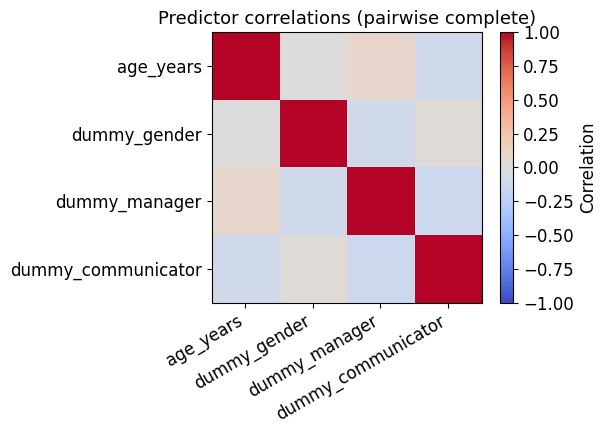

In [39]:
pred_cols = ["age_years", "dummy_gender", "dummy_manager", "dummy_communicator"]
corr_pw = df[pred_cols].corr()  # pairwise complete by default
print(corr_pw.round(3))

plt.figure(figsize=(6, 4.5))
plt.imshow(corr_pw.values, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(len(pred_cols)), pred_cols, rotation=30, ha="right")
plt.yticks(range(len(pred_cols)), pred_cols)
plt.title("Predictor correlations (pairwise complete)")
plt.tight_layout()

### Step 2: Check multicollinearity with VIF

In [40]:
# Build design matrix from the fitted model data (without intercept in formula terms)
X_vif = pd.get_dummies(
    df_clean[["age_years", "dummy_gender", "Org_type", "dummy_manager", "dummy_communicator"]],
    drop_first=True
).astype(float)
X_vif = sm.add_constant(X_vif, has_constant="add")

vif_rows = []
for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    vif_rows.append((col, variance_inflation_factor(X_vif.values, i)))

vif_df = pd.DataFrame(vif_rows, columns=["predictor", "VIF"])
print(vif_df.round(3))

            predictor    VIF
0           age_years  1.021
1        dummy_gender  1.143
2       dummy_manager  1.042
3  dummy_communicator  1.039
4     Org_type_Public  1.141


### Step 3: Residuals vs fitted values

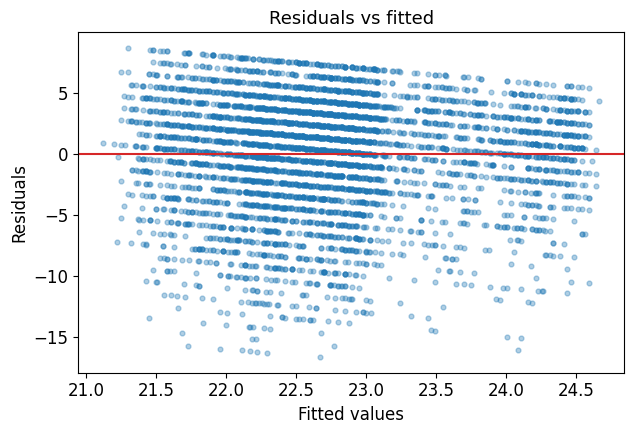

In [41]:
fitted = model.fittedvalues
resid = model.resid

plt.figure(figsize=(6.5, 4.5))
plt.scatter(fitted, resid, alpha=0.35, s=12)
plt.axhline(0, color="tab:red", linewidth=1.5)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted")
plt.tight_layout()

### Step 4: Normal Q-Q plot of residuals

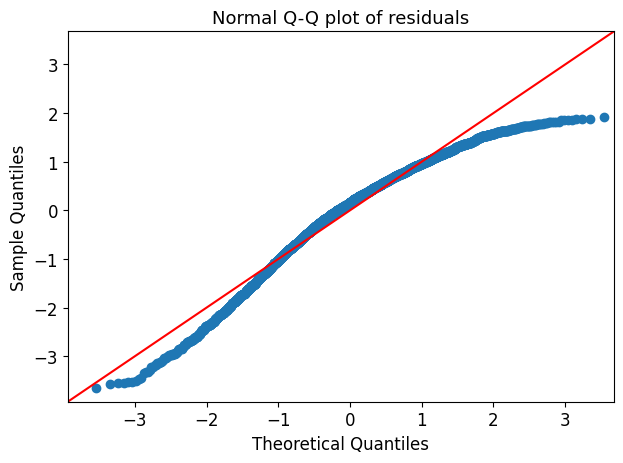

In [42]:
fig = sm.qqplot(model.resid, line="45", fit=True)
plt.title("Normal Q-Q plot of residuals")
plt.tight_layout()

### Step 5: Casewise diagnostics (large standardized residuals)

In [43]:
influence = model.get_influence()
std_resid = influence.resid_studentized_internal

flag = np.abs(std_resid) > 3
print("Potential outliers (|standardized residual| > 3):", int(flag.sum()))

if flag.sum() > 0:
    out = df_clean.loc[flag, cols].copy()
    out["std_resid"] = std_resid[flag]
    print(out.head(10))

Potential outliers (|standardized residual| > 3): 27
      infoaccess_index  age_years  dummy_gender Org_type  dummy_manager  \
659                9.0       57.0           1.0   Public            0.0   
671                8.0       45.0           1.0   Public            1.0   
754                9.0       46.0           1.0   Public            1.0   
773                6.0       57.0           0.0   Public            0.0   
1661               9.0       52.0           0.0   Public            1.0   
1817               8.0       33.0           1.0   Public            0.0   
1944               8.0       30.0           1.0   Public            0.0   
2056               6.0       51.0           0.0   Public            0.0   
2077               7.0       61.0           0.0   Public            0.0   
2832               6.0       38.0           0.0   Public            0.0   

      dummy_communicator  std_resid  
659                  0.0  -3.043606  
671                  0.0  -3.528971  
754    

## Wrap-up

This notebook now follows one clear workflow:
- specify model
- fit with `statsmodels` formula OLS
- inspect coefficients and model fit
- run core diagnostics (pairwise correlations, VIF, residual plots, casewise checks)

For Quarto conversion:
- `quarto convert jnb/lab3.qmd --to ipynb`